In [ ]:
print("Hello woeld")

## Usando o pandas para analisar o arquivo
---
* Caminho: C:\Users\joao.victor\MSGÁS\GEOP - Documentos\2026\Manutenção - 2026

In [ ]:
#instala as bibliotecas

#!pip install pandas
#!pip install openpyxl
#!pip install dotenv

In [67]:
#importa bibliotecas
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv


In [2]:
load_dotenv()

caminho = os.getenv("FILE_BASE_DATA")
try:
    df = pd.read_excel(caminho,
                       sheet_name='IFS_TASK_CLOCKING',
                       usecols=[
                            "TASK_SEQ",
                            "TASK_DESCRIPTION",
                            "CLOCKING_CATEGORY",
                            "CLOCKING_TYPE",
                            "START_TIME",
                            "STOP_TIME",
                            "WORK_HOURS",
                            "ORGANIZATION_ID",
                            "EMPLOYEE_ID"
                       ]
    )
    print("Carregado dataframe")
except Exception as e:
    print('Erro ao ler o excel', e)

Carregado dataframe


## Tratamento de dados
* Apenas colunas, Nome em PT-BR - Nome em ING-IFSfrescos
   * N° Tarefa - TASK_SEQ
   * Descr da Tarefa - TASK_DESCRIPTION
   * Categoria de Registro - CLOCKING_CATEGORY (Viagem ou serviço)
   * Tipo de Reg de Horas - CLOCKING_TYPE (Registro de saída ou de entrada)
   * Org de Manut - ORGANIZATION_ID
   * Horário de Início - START_TIME
   * Hora Parada - STOP_TIME
   * Horas Trab - WORK_HOURS
   * ID Recurso - EMPLOYEE_ID
* Limpa linhas que estão incompletas
* Modifica os dtypes das colunas
*

In [3]:
# mudando os nomes
df.rename(columns={"TASK_SEQ" : "ID_tarefa",
  "TASK_DESCRIPTION": "Descricao",
  "CLOCKING_CATEGORY": "Tipo_temporal",
  "CLOCKING_TYPE": "Valida_registro",
  "START_TIME": "Tempo_inicio",
  "STOP_TIME": "Tempo_fim",
  "WORK_HOURS": "Horas_trabalhadas",
  "ORGANIZATION_ID": "ORG_manut",
  "EMPLOYEE_ID": "TOM"}, inplace=True)

In [4]:
#Retirando dados que estão em execucao
df.dropna(axis=0, how='any', inplace=True)

In [5]:
#Retira serviços de terceiros ORG MANUT -> != MCGR, OCGR, TLG
filtroMCGR = df["ORG_manut"] == "MCGR"
filtroOCGR = df["ORG_manut"] == "OCGR"
filtroTLG = df["ORG_manut"] == "TLG"
df = df[filtroMCGR | filtroTLG | filtroOCGR]

In [6]:
# Formata os tempo_inicio e tempo_fim
#       função de formatação
def formata_data(d):
    #Variaveis
    r = str(d) #Variavel de retorno
    month_number = {
        "jan": "01",
        "feb": "02",
        "mar": "03",
        "apr": "04",
        "may": "05",
        "jun": "06",
        "jul": "07",
        "aug": "08",
        "sep": "09",
        "oct": "10",
        "nov": "11",
        "dec": "12"
    } # Dicionario conversor de mes de nome para numero
    r = r.strip().lower().split() #tirando espaços e deoxando tudo minusculo
    day = r[1].replace(",", " ").strip()
    month = month_number[r[0]]
    year = r[2][:4]
    hour = pd.to_timedelta(r[3]) + pd.to_timedelta("12:00:00") if r[4] == "pm" else pd.to_timedelta(r[3]) #horas "brasileiras"
    hour = str(hour)[-8:] # Transform o dado em string
    #Formato antes: May 5, 2026, 2:37:30 PM
    #Formato que deve ficar 05/05/2026 02:37:30
    return day + "/" + month + "/" + year + " " + hour
#       aplica função de formatação
df["Tempo_inicio"] = df["Tempo_inicio"].apply(formata_data)
df["Tempo_fim"] = df["Tempo_fim"].apply(formata_data)

In [7]:
# Formata colunas de tempo para deltatime
df["Tempo_inicio"] = pd.to_datetime(df["Tempo_inicio"], format="%d/%m/%Y %H:%M:%S")
df["Tempo_fim"] = pd.to_datetime(df["Tempo_fim"], format="%d/%m/%Y %H:%M:%S")

In [13]:
#Seleciona um periodo para analisar
filtro_temporal = df["Tempo_inicio"].between(pd.to_datetime("05/01/2026"), pd.to_datetime("05/31/2026")) #Mês de maio
df_periodo = df[filtro_temporal]

## Analisando dados
1. O serviço realizado teve viajem? (sim positivo)
2. O tempo de viajem foi maior que 4min? (sim positivo)

    __Serviços que não tem viagem__
    1. Café da firma
    2. Troca de sobreaviso%
    2. Patrulha%
    2. Calibrar esta%
    2. Calibrar torr%
    2. Consolidação de clientes
    2. Palestra%
    2. EQS - Momento de segurança com GESMA
    2. Transferência de odorante e recarga de tanque da odorizadora
    2. Treinamento%
    2. Rest

3. Acompanhamento pessoal

In [52]:
# 1. SERVIÇO TEVE VIAGEM
filtro_Viagem = df_periodo["Tipo_temporal"] == "Viagem"
filtro_Serviço = df_periodo["Tipo_temporal"] == "Serviço"
tarefas_viagem = np.array(df_periodo[filtro_Viagem]["ID_tarefa"], dtype=np.int32)
tarefas_Serviço = np.array(df_periodo[filtro_Serviço]["ID_tarefa"], dtype=np.int32)

filtro_serviço_com_viagem = np.isin(tarefas_Serviço, tarefas_viagem)

In [96]:
Serviços = df_periodo[filtro_Serviço]
Viagens = df_periodo[filtro_Viagem]

Viagens

,ID_tarefa,Tempo_inicio,Tipo_temporal,Valida_registro,TOM,Tempo_fim,ORG_manut,Descricao,Horas_trabalhadas
308,206275,2026-05-30 09:47:28,Viagem,Saída Registrada,GUSTAVOG,2026-05-30 09:55:15,OCGR,LER MEDIDOR - JBS,0.1297
440,206174,2026-05-30 07:06:28,Viagem,Saída Registrada,MERIVAN,2026-05-30 07:32:41,TLG,TLG1-VE-02 - Inspeção rotineira da Estação,0.4369
442,206173,2026-05-30 06:53:59,Viagem,Saída Registrada,MERIVAN,2026-05-30 06:58:41,TLG,CARGILL - Inspeção rotineira da Estação,0.0783
453,206164,2026-05-30 08:41:35,Viagem,Saída Registrada,MERIVAN,2026-05-30 09:25:48,TLG,ESTAÇÃO SITREL - Inspeção rotineira da Estação,0.7369
490,206129,2026-05-29 08:19:51,Viagem,Saída Registrada,ELVIS,2026-05-29 09:16:36,OCGR,ACOMPANHAMENTO TÉCNICO - RUA DA DIVISÃO N° 2218,0.9458
...,...,...,...,...,...,...,...,...,...
4074,203338,2026-05-20 14:03:30,Viagem,Saída Registrada,GILMARB,2026-05-20 14:03:32,MCGR,Preparar estação - SEARA,0.0006
4079,203338,2026-05-25 08:40:40,Viagem,Saída Registrada,GILMARB,2026-05-25 08:40:44,MCGR,Preparar estação - SEARA,0.0011
5313,202478,2026-05-11 16:40:39,Viagem,Saída Registrada,CLAUDENIS,2026-05-11 16:56:00,OCGR,Inspeção de aterramento,0.2558
5314,202478,2026-05-11 14:06:56,Viagem,Saída Registrada,CLAUDENIS,2026-05-11 15:30:17,OCGR,Inspeção de aterramento,1.3892


In [95]:
filtro_longa = Viagens["Horas_trabalhadas"] > 8
filtro_curta = Viagens["Horas_trabalhadas"] < 4/60
filtro_OK = filtro_longa & ~filtro_curta & ~filtro_longa

viagem_longa = np.array(Viagens[filtro_longa]) #tempo de viagem maior que oito horas
viagem_curta = np.array(Viagens[filtro_curta]) #tempo de viagem menos que 4 minutos
viagem_ok = np.array(Viagens[filtro_OK])

Viagens[filtro_curta].to_csv(r".\Data\Viagens.csv", index=False, encoding="latin1", sep=";")

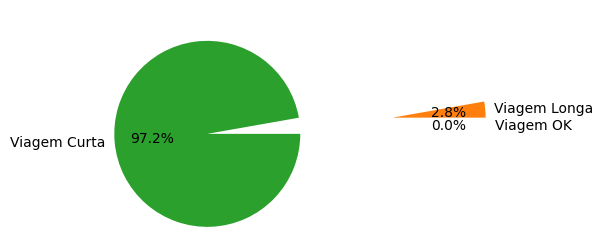

In [91]:
plt.figure(figsize=(3, 5))
plt.pie(
    [len(viagem_ok),len(viagem_longa),len(viagem_curta)],
    autopct='%1.1f%%',
    labels = ["Viagem OK", "Viagem Longa", "Viagem Curta"],
    explode=[1, 1, 1]
)

plt.show()

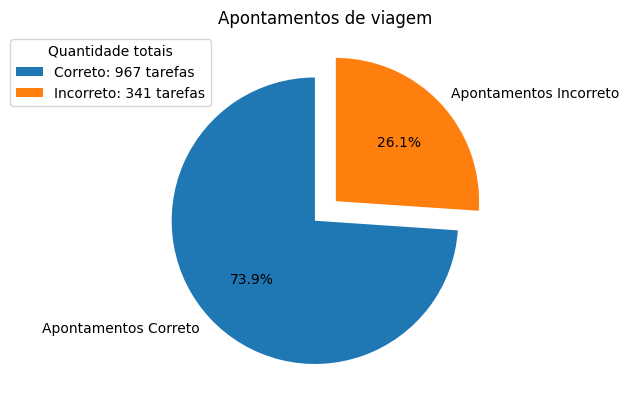

In [77]:
# PLOTAGEM DO GRAFICO
#   Valores utilizados
OK = len(Serviços[filtro_serviço_com_viagem])#Serviços com viagem
no_OK = len(Serviços) - OK#Serviços sem viagem (todos serviços - com viagem)
#   CRIAÇÃO DO GRAFICO DE PIZZA
fig, ax = plt.subplots(figsize=(6, 6))

fatias, textos, autotextos = ax.pie(
    [OK, no_OK],
    labels=["Apontamentos Correto", "Apontamentos Incorreto"],
    explode=[0.1, 0.1],
    autopct='%1.1f%%',
    startangle=90
)

labels_com_quantidade = [
    f"Correto: {OK} tarefas",
    f"Incorreto: {no_OK} tarefas"
]

ax.legend(
    fatias,
    labels_com_quantidade,
    title="Quantidade totais",
    loc="upper right",
    bbox_to_anchor=(0.2, 1),
)

ax.set_title("Apontamentos de viagem")

plt.tight_layout()
plt.show()

0.018